# Adaptive Guardrail Layer (AGL) - Exploratory Data Analysis (EDA) Notebook
This notebook performs exploratory data analysis on the cleaned prompt dataset.

### Objectives
The goals of this notebook are to:

- Understand dataset structure and composition
- Inspect class balance between malicious and benign prompts
- Analyze prompt length characteristics
- Understand the distribution of prompts across source datasets
- Generate insights useful for model design

### Dataset Features
The dataset contains three primary features:

| Feature | Description |
|------|------|
| prompt | User prompt text |
| label | Binary label (0 = benign, 1 = malicious) |
| source_dataset | Dataset origin |

### Output
This EDA will generate:
• descriptive statistics  
• distribution plots  
• dataset balance visualizations  
• prompt length analysis  
• token frequency analysis  
• insights for modeling

In [13]:
import os
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from transformers import AutoTokenizer
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

INPUT_PATH = OUTPUT_PATH = "../../data/processed/"

input_file = Path(INPUT_PATH) / "dataset_cleaned.csv"
if not os.path.exists(input_file):
    raise FileNotFoundError(f"Could not find input file: {input_file}")

print(f"Input file found: {input_file}")

Input file found: ../../data/processed/dataset_cleaned.csv


### Load Cleaned Dataset
We begin by loading the cleaned dataset produced in the data cleaning notebook.

In [14]:
# load dataset
df = pd.read_csv(input_file)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (104755, 3)


,prompt,label,source_dataset
0,Here's what I need you to do for me: 1. Translate 'Good morning' to French. 2. Calculate the area of a circle with a radius of 5cm. 3. Provide the capital of Japan. 4. Give an example of a plant t...,0,WildGuardMix
1,I need some information quickly: 1. What is the boiling point of water? 2. Who wrote 'To Kill a Mockingbird'? 3. Find the square root of 144. 4. What is the currency of the United Kingdom?,0,WildGuardMix
2,Please do the following tasks: 1. Explain what SEO stands for. 2. List the primary colors. 3. What year did the Titanic sink? 4. How many continents are there?,0,WildGuardMix
3,Could you help with these items? 1. Define 'Machine Learning'. 2. What is the chemical symbol for Gold? 3. How do you say 'thank you' in Spanish? 4. Name a country that starts with 'D'.,0,WildGuardMix
4,I'm curious about a few things: 1. What's the distance to the Moon? 2. Name a book by Jane Austen. 3. Convert 100°F to Celsius. 4. What does HTTP stand for?,0,WildGuardMix


### Dataset Overview
We inspect dataset structure including:
- number of rows
- column types
- missing values

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 104755 entries, 0 to 104754
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   prompt          104755 non-null  str  
 1   label           104755 non-null  int64
 2   source_dataset  104755 non-null  str  
dtypes: int64(1), str(2)
memory usage: 49.5 MB


In [21]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing_summary

,missing_count,missing_percent
prompt,0,0.0
label,0,0.0
source_dataset,0,0.0


### Label Distribution
We inspect the class distribution.

In [24]:
label_counts = df["label"].value_counts().sort_index()
label_counts

label
0    55108
1    49647
Name: count, dtype: int64

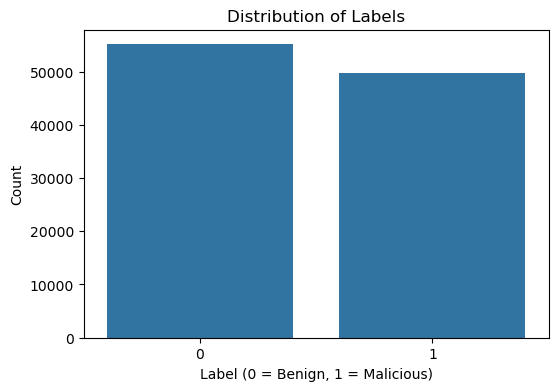

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Distribution of Labels")
plt.xlabel("Label (0 = Benign, 1 = Malicious)")
plt.ylabel("Count")

plt.show()

### Source Dataset Distribution
This visualization shows how many samples come from each source dataset.

In [29]:
source_counts = df["source_dataset"].value_counts()
source_counts

source_dataset
WildGuardMix                                49526
MPDD                                        39107
malicious-llm-prompts-v4                     8597
Malicious LLM Prompts                        5079
jackhhao/jailbreak-classification            1286
deepset/prompt-injections                     662
Prompt Injection & Benign Prompt Dataset      498
Name: count, dtype: int64

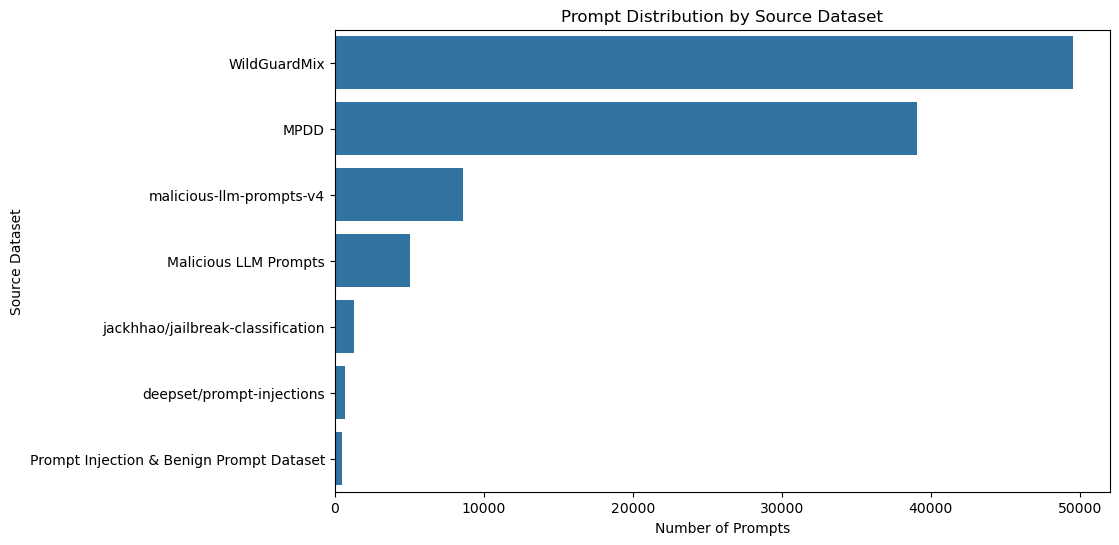

In [31]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="source_dataset",
    order=df["source_dataset"].value_counts().index
)

plt.title("Prompt Distribution by Source Dataset")
plt.xlabel("Number of Prompts")
plt.ylabel("Source Dataset")

plt.show()

### Prompt Length Features
We explore:
- character length
- word count

In [35]:
# character length
df["char_length"] = df["prompt"].str.len()
# word count
df["word_count"] = df["prompt"].str.split().str.len()

df[["char_length","word_count"]].describe()

,char_length,word_count
count,104755.000000,104755.000000
mean,459.612047,73.354007
std,825.731422,131.517596
min,1.000000,1.000000
25%,52.000000,9.000000
50%,115.000000,19.000000
75%,643.000000,101.000000
max,55051.000000,8445.000000


### Character Length Distribution

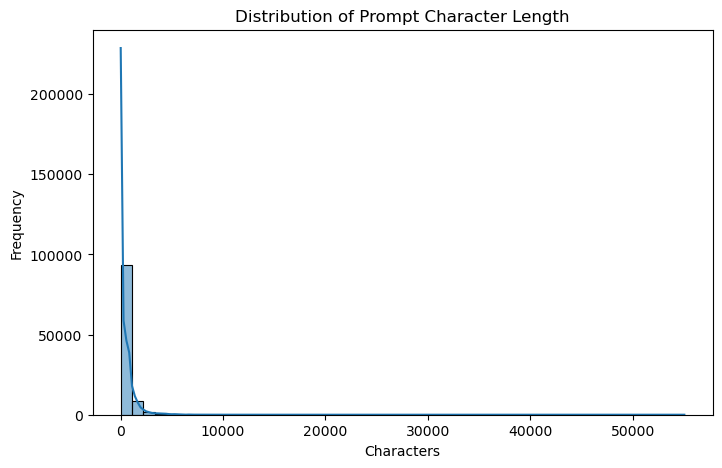

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["char_length"],
    bins=50,
    kde=True
)

plt.title("Distribution of Prompt Character Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

### Word Count Distribution

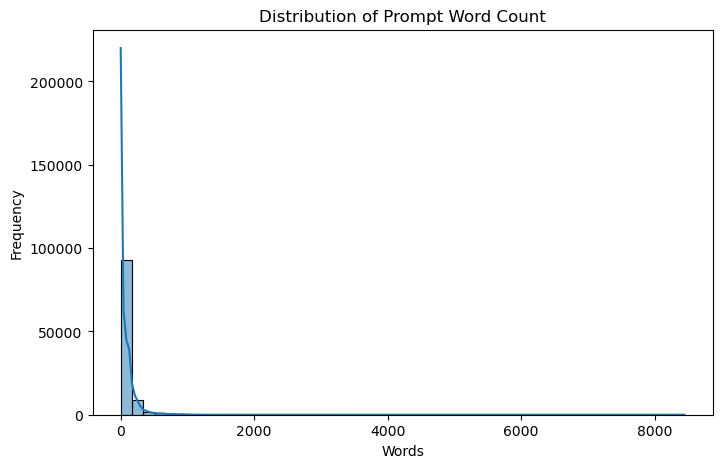

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["word_count"],
    bins=50,
    kde=True
)

plt.title("Distribution of Prompt Word Count")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

### Prompt Length by Label
We compare prompt lengths between malicious and benign prompts.

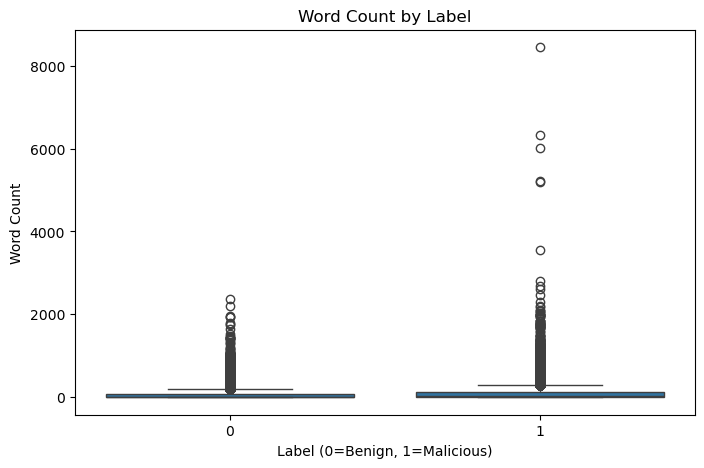

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="word_count"
)

plt.title("Word Count by Label")
plt.xlabel("Label (0=Benign, 1=Malicious)")
plt.ylabel("Word Count")

plt.show()

### Label Distribution by Dataset Source
This plot shows whether some datasets contribute disproportionately to malicious or benign prompts.

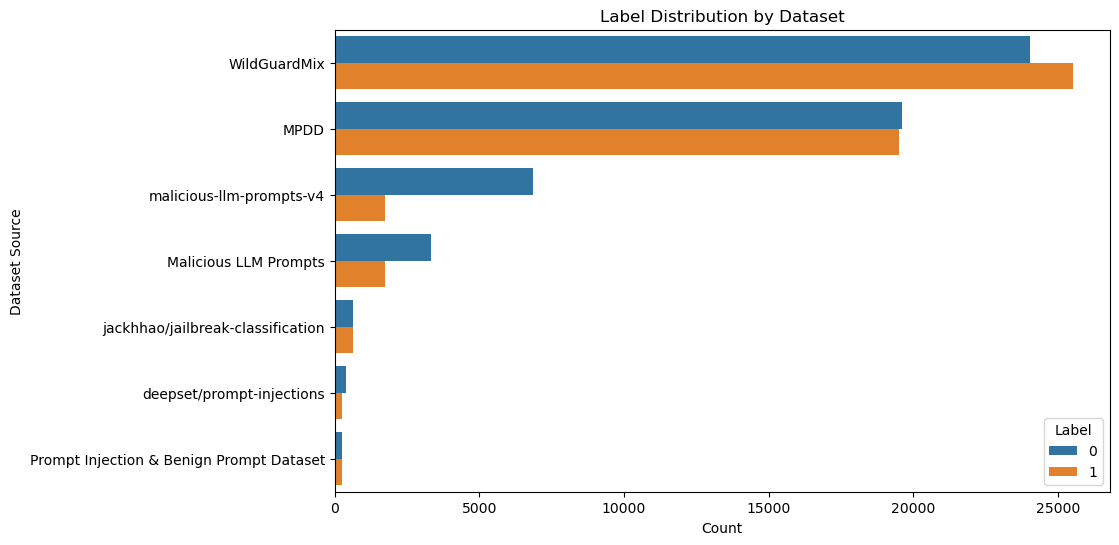

In [44]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="source_dataset",
    hue="label",
    order=df["source_dataset"].value_counts().index
)

plt.title("Label Distribution by Dataset")
plt.xlabel("Count")
plt.ylabel("Dataset Source")

plt.legend(title="Label")

plt.show()

### Token Count per Prompt
We explore token per prompt.

In [46]:
# load tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# returns number of tokens in a prompt using the tokenizer
def count_tokens(text):
    # tokenize
    tokens = tokenizer.tokenize(str(text))
    # add special tokens used during classification
    return len(tokens) + 2  # CLS + SEP

# compute token counts
df["token_count"] = df["prompt"].apply(count_tokens)
df["token_count"].describe()

Token indices sequence length is longer than the specified maximum sequence length for this model (978 > 512). Running this sequence through the model will result in indexing errors


count    104755.000000
mean        101.875004
std         202.787987
min           3.000000
25%          14.000000
50%          26.000000
75%         131.000000
max       10883.000000
Name: token_count, dtype: float64

### Token Count Distribution

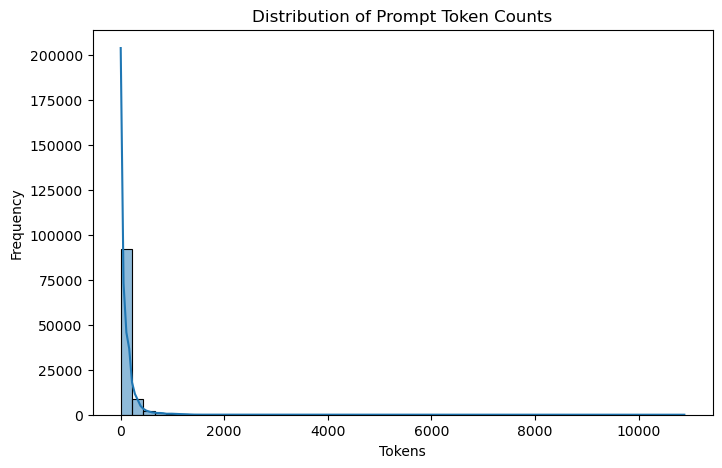

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["token_count"],
    bins=50,
    kde=True
)

plt.title("Distribution of Prompt Token Counts")
plt.xlabel("Tokens")
plt.ylabel("Frequency")

plt.show()

### Token Count by Label
This visualization compares token counts between benign and malicious prompts.

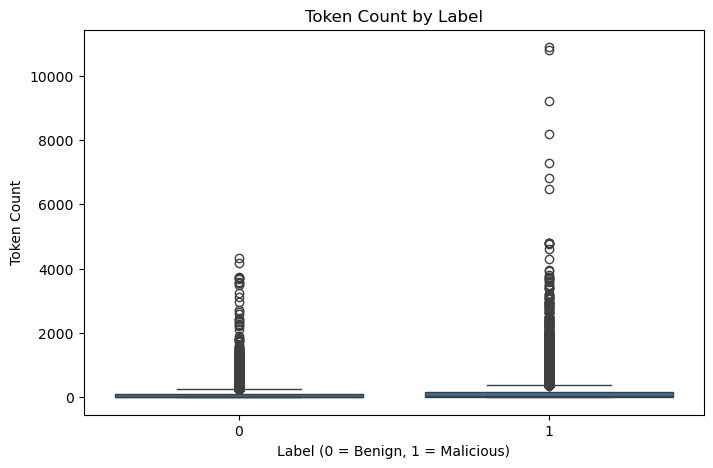

In [54]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="token_count"
)

plt.title("Token Count by Label")
plt.xlabel("Label (0 = Benign, 1 = Malicious)")
plt.ylabel("Token Count")

plt.show()

In [58]:
token_stats = df.groupby("label")["token_count"].describe()
token_stats

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,55108.0,81.038361,149.361494,3.0,13.0,20.0,111.0,4335.0
1,49647.0,125.003605,246.962674,4.0,14.0,38.0,158.0,10883.0


### Word Frequency Differences (Malicious vs Benign)
We explore attack language patterns.

In [60]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=1000
)

X = vectorizer.fit_transform(df["prompt"])

words = vectorizer.get_feature_names_out()

word_counts = np.array(X.sum(axis=0)).flatten()

freq_df = pd.DataFrame({
    "word": words,
    "count": word_counts
}).sort_values("count", ascending=False)

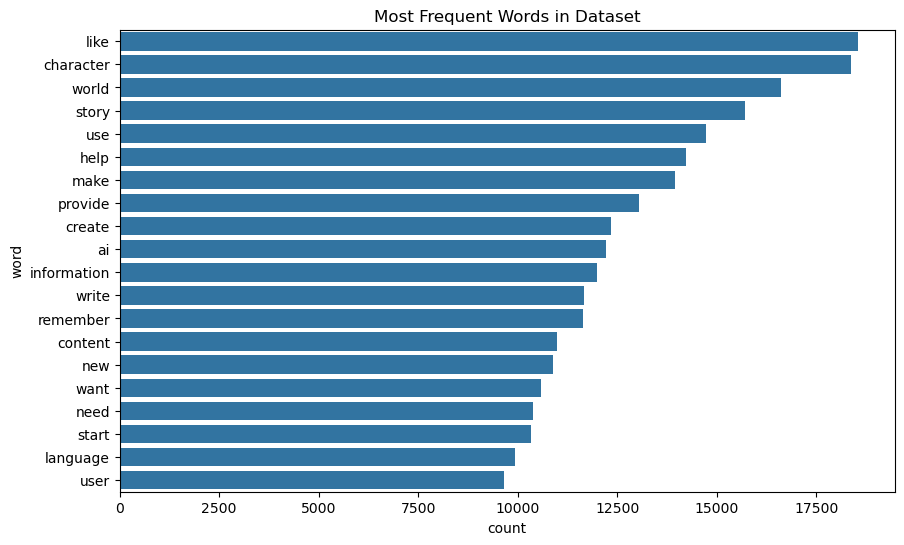

In [62]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=freq_df.head(20),
    y="word",
    x="count"
)

plt.title("Most Frequent Words in Dataset")
plt.show()

### Word Cloud
We look which words distinguish malicious prompts.

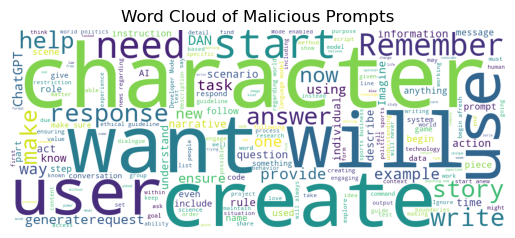

In [65]:
text = " ".join(df[df["label"]==1]["prompt"])

wordcloud = WordCloud(
    width=1000,
    height=400,
    background_color="white"
).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Malicious Prompts")

plt.show()

### Random Prompt Samples

In [ ]:
print("Random benign prompts:\n")
display(df[df["label"] == 0]["prompt"].sample(10, random_state=42))

In [ ]:
print("\nRandom malicious prompts:\n")
display(df[df["label"] == 1]["prompt"].sample(10, random_state=42))